# 09. Generalized Linear Models for Binary, Count, and Rate Data

Linear regression is a powerful inferential baseline, but many real decision outcomes are not continuous and approximately Gaussian. Organizations often care about whether a failure happened, how many failures occurred, or how often failures occurred per unit of exposure. Those questions call for models that respect the geometry of the outcome itself.

We develop generalized linear models in exactly that spirit. We will work with one synthetic but realistic SaaS reliability dataset and study three common operational outcomes:

1. whether an account breached its service-level agreement in a month,
2. how many escalations it generated, and
3. how many severe incidents occurred relative to total deployment exposure.

The statistical goal is to fit models that match the outcome scale and decision problem. It is to learn how link functions, mean structures, and offsets let us turn binary, count, and rate outcomes into interpretable evidence for operational decisions.


## Learning Objectives

After working through this lecture, you should be able to:

1. explain why generalized linear models extend linear regression to binary, count, and rate outcomes;
2. write down and interpret the logistic and Poisson mean structures used in common operational analyses;
3. translate logistic coefficients into odds ratios and Poisson coefficients into incidence-rate ratios;
4. understand why a raw treated-versus-untreated comparison can disagree with an adjusted GLM estimate;
5. diagnose why overdispersion matters for count-data inference;
6. explain what an offset does and why it is essential for rate modeling;
7. compare a count model without an offset to a rate model with an offset; and
8. synthesize binary, count, and rate predictions into one decision-facing recommendation.


In [1]:
# Load GLM, plotting, and display tools used throughout the binary/count/rate examples.
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
from IPython.display import Markdown, display
from scipy.special import expit

for candidate in [Path.cwd(), *Path.cwd().parents]:
    if (candidate / "notebooks" / "_shared" / "display.py").exists():
        if str(candidate) not in sys.path:
            sys.path.insert(0, str(candidate))
        break

from notebooks._shared.display import smart_display

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.float_format", lambda x: f"{x:0.3f}")
pd.set_option("display.max_columns", 40)
pd.set_option("display.max_colwidth", 200)
np.random.seed(2026)

PLAN_ORDER = ["Standard", "Professional", "Enterprise"]
REGION_ORDER = ["North America", "Europe", "Asia Pacific", "Latin America"]


def make_reliability_glm_data(seed=2026, n_rows=3600):
    """
    Simulate a SaaS reliability dataset with binary, count, and rate outcomes.
    
    Parameters:
        seed: Random seed used to make the simulation reproducible.
        n_rows: Number of monthly account records to generate.
    
    Returns:
        A pandas DataFrame with account complexity variables, monitoring assignment, SLA breaches, escalation counts, severe-incident counts, and deployment exposure.
    
    Idea:
        Create one coherent operational setting where logistic, Poisson count, and Poisson rate models answer different but related decision questions.
    """
    rng = np.random.default_rng(seed)

    plan_tier = rng.choice(PLAN_ORDER, size=n_rows, p=[0.42, 0.35, 0.23])
    plan_score = pd.Series(plan_tier).map({"Standard": 0, "Professional": 1, "Enterprise": 2}).to_numpy()
    region = rng.choice(REGION_ORDER, size=n_rows, p=[0.36, 0.24, 0.28, 0.12])

    integration_count = np.clip(rng.poisson(4 + 2 * plan_score), 0, None)
    usage_millions = np.exp(rng.normal(1.05 + 0.42 * plan_score, 0.55, n_rows))
    prior_incidents = rng.poisson(np.clip(0.5 + 0.22 * integration_count + 0.18 * plan_score, 0.1, None))
    ops_maturity = np.clip(rng.normal(0, 1, n_rows) + 0.15 * plan_score, -2.5, 2.5)
    weekend_release = rng.binomial(1, expit(-1.4 + 0.18 * integration_count + 0.14 * plan_score))
    deploy_hours = np.exp(rng.normal(3.0 + 0.55 * plan_score + 0.35 * np.log(usage_millions), 0.50, n_rows))

    complexity_index = (
        0.28 * integration_count
        + 0.22 * np.log(usage_millions)
        + 0.50 * weekend_release
        + 0.30 * prior_incidents
        + 0.18 * plan_score
        - 0.28 * ops_maturity
        + 0.25 * np.log(deploy_hours)
    )
    monitoring_probability = expit(
        -2.45
        + 0.46 * complexity_index
        + 0.30 * plan_score
        + 0.26 * (region == "Latin America")
        + 0.38 * np.log(deploy_hours)
    )
    priority_monitoring = rng.binomial(1, monitoring_probability)

    breach_probability = expit(
        -3.35
        + 0.26 * integration_count
        + 0.24 * np.log(usage_millions)
        + 0.45 * weekend_release
        + 0.23 * prior_incidents
        + 0.14 * plan_score
        - 0.40 * ops_maturity
        - 0.62 * priority_monitoring
    )
    sla_breach = rng.binomial(1, breach_probability)

    escalation_mean = np.exp(
        0.05
        + 0.12 * integration_count
        + 0.17 * np.log(usage_millions)
        + 0.28 * weekend_release
        + 0.11 * prior_incidents
        + 0.08 * plan_score
        - 0.15 * ops_maturity
        - 0.20 * priority_monitoring
    )
    gamma_phi = 1.7
    gamma_noise = rng.gamma(shape=gamma_phi, scale=1 / gamma_phi, size=n_rows)
    escalation_count = rng.poisson(escalation_mean * gamma_noise)

    sev1_rate = np.exp(
        -4.75
        + 0.08 * integration_count
        + 0.19 * weekend_release
        + 0.16 * prior_incidents
        + 0.06 * plan_score
        - 0.17 * ops_maturity
        - 0.42 * priority_monitoring
        + 0.16 * (region == "Latin America")
    )
    sev1_count = rng.poisson(deploy_hours * sev1_rate)

    df = pd.DataFrame(
        {
            "plan_tier": plan_tier,
            "region": region,
            "integration_count": integration_count,
            "usage_millions": usage_millions,
            "prior_incidents": prior_incidents,
            "ops_maturity": ops_maturity,
            "weekend_release": weekend_release,
            "deploy_hours": deploy_hours,
            "priority_monitoring": priority_monitoring,
            "monitoring_probability": monitoring_probability,
            "sla_breach": sla_breach,
            "breach_probability": breach_probability,
            "escalation_count": escalation_count,
            "escalation_mean": escalation_mean,
            "sev1_count": sev1_count,
            "sev1_rate": sev1_rate,
        }
    )
    df["plan_tier"] = pd.Categorical(df["plan_tier"], categories=PLAN_ORDER, ordered=True)
    df["region"] = pd.Categorical(df["region"], categories=REGION_ORDER, ordered=True)
    return df


def raw_monitoring_summary(df):
    """
    Summarize unadjusted reliability outcomes by monitoring status.
    
    Parameters:
        df: Reliability dataset containing monitoring status, outcomes, and deployment exposure.
    
    Returns:
        A pandas DataFrame comparing account counts, raw breach rates, mean escalation counts, mean severe-incident counts, and exposure-normalized incident rates.
    
    Idea:
        Show why monitored accounts look worse descriptively before adjustment, setting up the need for GLMs on the correct outcome scale.
    """
    grouped = df.groupby("priority_monitoring")
    rows = []
    for monitoring, frame in grouped:
        rows.append(
            {
                "priority_monitoring": monitoring,
                "monitoring_label": "Priority monitoring" if monitoring == 1 else "No priority monitoring",
                "accounts": len(frame),
                "sla_breach_rate": frame["sla_breach"].mean(),
                "mean_escalations": frame["escalation_count"].mean(),
                "mean_sev1_count": frame["sev1_count"].mean(),
                "mean_deploy_hours": frame["deploy_hours"].mean(),
                "sev1_per_1000_deploy_hours": 1000 * frame["sev1_count"].sum() / frame["deploy_hours"].sum(),
            }
        )
    return pd.DataFrame(rows)


def ratio_table(model, term_labels, ratio_name):
    """
    Convert selected GLM coefficients into exponentiated effect-ratio summaries.
    
    Parameters:
        model: Fitted statsmodels GLM result.
        term_labels: Mapping from model coefficient names to human-readable labels.
        ratio_name: Name to use for the exponentiated coefficient column, such as `odds_ratio` or `incidence_rate_ratio`.
    
    Returns:
        A pandas DataFrame with link-scale estimates, standard errors, confidence intervals, and exponentiated ratios.
    
    Idea:
        Put GLM coefficients on a multiplicative scale that is easier to interpret for odds, counts, and rates.
    """
    conf_int = model.conf_int()
    rows = []
    for term, label in term_labels.items():
        lower, upper = conf_int.loc[term]
        rows.append(
            {
                "term": term,
                "label": label,
                "estimate": model.params[term],
                "std_error": model.bse[term],
                "ci_lower": lower,
                "ci_upper": upper,
                ratio_name: np.exp(model.params[term]),
                f"{ratio_name}_ci_lower": np.exp(lower),
                f"{ratio_name}_ci_upper": np.exp(upper),
            }
        )
    return pd.DataFrame(rows)


def single_effect_row(model, term, label, ratio_name):
    """
    Summarize one GLM coefficient as a link-scale estimate and exponentiated ratio.
    
    Parameters:
        model: Fitted statsmodels GLM result.
        term: Model coefficient name to summarize.
        label: Human-readable model or effect label.
        ratio_name: Name to use for the exponentiated coefficient column.
    
    Returns:
        A dictionary containing the coefficient, exponentiated ratio, and ratio confidence limits.
    
    Idea:
        Extract one monitoring effect so count and rate models can be compared in a compact table and plot.
    """
    lower, upper = model.conf_int().loc[term]
    return {
        "model": label,
        "estimate": model.params[term],
        ratio_name: np.exp(model.params[term]),
        f"{ratio_name}_ci_lower": np.exp(lower),
        f"{ratio_name}_ci_upper": np.exp(upper),
    }


def prediction_table_with_ci(model, scenarios, *, offset=None, kind="mean"):
    """
    Generate scenario-level GLM predictions with confidence intervals.
    
    Parameters:
        model: Fitted statsmodels GLM result used for prediction.
        scenarios: DataFrame of account scenarios and monitoring states to evaluate.
        offset: Optional exposure offset passed to the prediction call for rate models.
        kind: Descriptive label for the prediction scale, such as `probability` or `mean`.
    
    Returns:
        A pandas DataFrame with scenario labels, monitoring status, predicted means, and confidence limits on the outcome scale.
    
    Idea:
        Translate link-scale GLM output into probabilities, expected counts, or rates that stakeholders can read directly.
    """
    pred = model.get_prediction(scenarios, offset=offset).summary_frame(alpha=0.05)
    out = pd.concat([scenarios.reset_index(drop=True), pred.reset_index(drop=True)], axis=1)
    if kind == "probability":
        keep = ["scenario", "priority_monitoring", "mean", "mean_ci_lower", "mean_ci_upper"]
    else:
        keep = ["scenario", "priority_monitoring", "mean", "mean_ci_lower", "mean_ci_upper"]
    return out[keep].copy()

## 1. Why Generalized Linear Models Matter

Generalized linear models (GLMs) take the core logic of regression and adapt it to outcomes whose support is not the whole real line. Nelder and Wedderburn (1972) introduced this framework by combining three ingredients:

1. a response distribution from the exponential family,
2. a linear predictor built from covariates, and
3. a link function connecting the mean of the outcome to that predictor.

The crucial change is conceptual. We are no longer forcing every outcome into a Gaussian, constant-variance story. Instead, we let the model geometry match the outcome:

- for a binary outcome, the mean is a probability and must stay between 0 and 1;
- for a count outcome, the mean must stay nonnegative;
- for a rate outcome, the mean often needs to scale with exposure, which is where an offset enters.


### Reading GLM Coefficients

| Model type | Mean structure | Interpretation habit |
|---|---|---|
| Logistic regression | $\log\left(\frac{p_i}{1-p_i}\right) = x_i^\top \beta$ | A one-unit coefficient shift changes **log-odds**; exponentiating gives an **odds ratio** |
| Poisson regression | $\log E[Y_i \mid X_i] = x_i^\top \beta$ | A coefficient changes the **log expected count**; exponentiating gives an **incidence-rate ratio** |
| Poisson rate model with offset | $\log E[Y_i \mid X_i, e_i] = \log e_i + x_i^\top \beta$ | The offset handles exposure so exponentiated coefficients describe **multiplicative rate changes** |

This table is static on purpose. It is interpretive scaffolding, not a computed result. The actual estimates, intervals, and scenario predictions should still come from the fitted models below.


## 2. Setup: A SaaS Reliability Program

Suppose a software company can place selected accounts into a **priority monitoring** program. Monitored accounts receive extra reliability review, proactive triage, and faster coordination during risky releases.

The decision problem is immediate: the program is expensive, so leadership wants evidence that it reduces operational failures. But the assignment is highly nonrandom. Large, integration-heavy, historically unstable accounts are much more likely to be monitored.

That creates the same inferential danger we saw in earlier notebooks: raw descriptive comparisons can make a helpful program look harmful because the treated accounts are systematically harder.


,plan_tier,region,integration_count,usage_millions,prior_incidents,ops_maturity,weekend_release,deploy_hours,priority_monitoring,monitoring_probability,sla_breach,breach_probability,escalation_count,escalation_mean,sev1_count,sev1_rate
0,Standard,Asia Pacific,5,3.916,0,1.416,0,13.357,0,0.362,0,0.092,1,1.954,0,0.010
1,Professional,North America,8,1.782,4,-1.012,0,36.628,1,0.816,1,0.429,10,4.855,0,0.026
2,Professional,Europe,12,3.284,1,0.093,1,35.617,1,0.849,0,0.554,12,7.016,1,0.022
3,Standard,Europe,4,2.996,1,0.237,0,23.445,0,0.461,0,0.129,0,2.205,0,0.013
4,Standard,Europe,4,2.417,0,-0.001,0,10.285,0,0.334,0,0.109,10,1.974,0,0.012


,priority_monitoring,monitoring_label,accounts,sla_breach_rate,mean_escalations,mean_sev1_count,mean_deploy_hours,sev1_per_1000_deploy_hours
0,0,No priority monitoring,1114,0.228,3.140,0.793,44.019,18.007
1,1,Priority monitoring,2486,0.278,4.289,1.469,78.112,18.807


,outcome,mean,variance
0,sla_breach,0.263,0.194
1,escalation_count,3.934,24.709
2,sev1_count,1.260,3.509


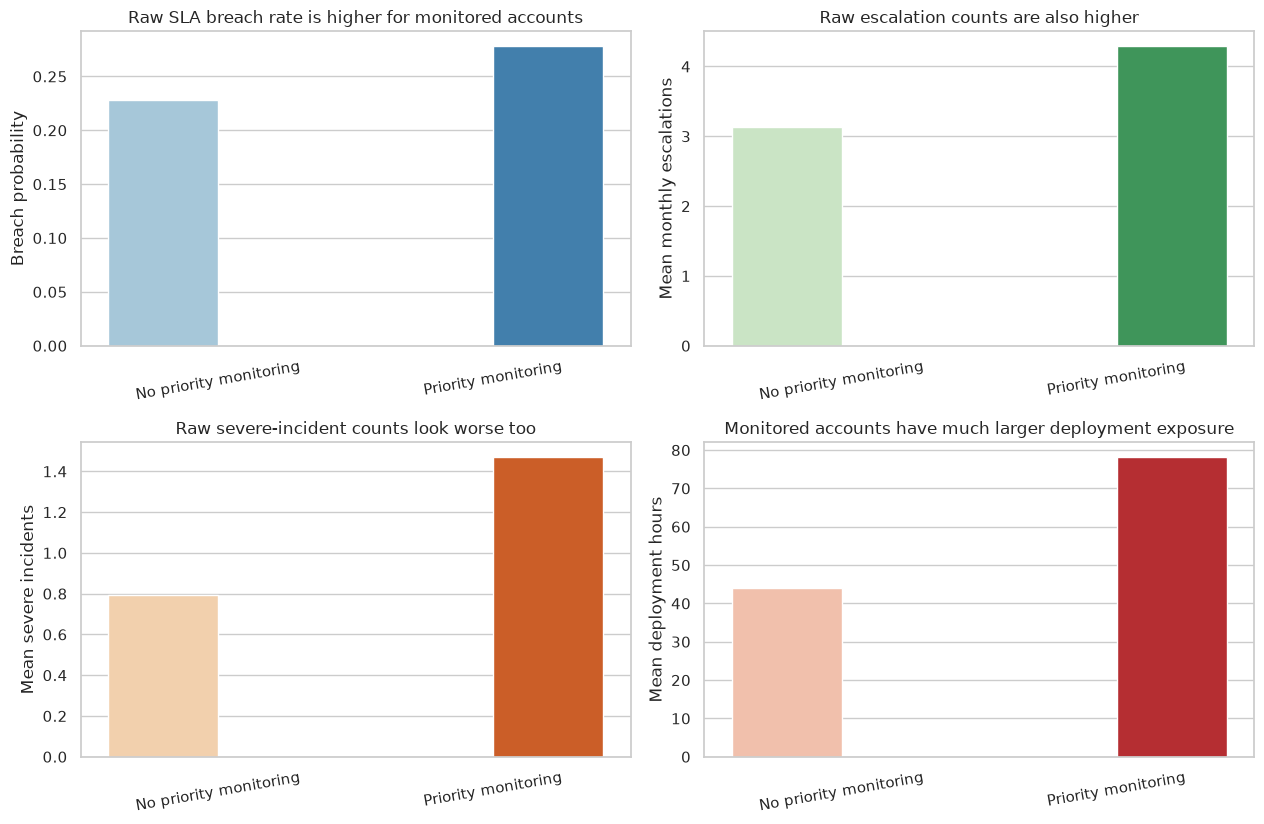

In [2]:
# Simulate reliability outcomes and show why raw monitored accounts look worse before adjustment.
df = make_reliability_glm_data()

smart_display(df.head())

raw_summary = raw_monitoring_summary(df)
smart_display(raw_summary)

distribution_summary = pd.DataFrame(
    [
        {
            "outcome": "sla_breach",
            "mean": df["sla_breach"].mean(),
            "variance": df["sla_breach"].var(),
        },
        {
            "outcome": "escalation_count",
            "mean": df["escalation_count"].mean(),
            "variance": df["escalation_count"].var(),
        },
        {
            "outcome": "sev1_count",
            "mean": df["sev1_count"].mean(),
            "variance": df["sev1_count"].var(),
        },
    ]
)
smart_display(distribution_summary)

plot_summary = raw_summary.copy()
plot_summary["monitoring_label"] = pd.Categorical(
    plot_summary["monitoring_label"],
    categories=["No priority monitoring", "Priority monitoring"],
    ordered=True,
)

fig, axes = plt.subplots(2, 2, figsize=(12.8, 8.4))

sns.barplot(
    data=plot_summary,
    x="monitoring_label",
    y="sla_breach_rate",
    hue="monitoring_label",
    order=["No priority monitoring", "Priority monitoring"],
    palette=["#9ecae1", "#3182bd"],
    legend=False,
    ax=axes[0, 0],
)
axes[0, 0].set_title("Raw SLA breach rate is higher for monitored accounts")
axes[0, 0].set_xlabel("")
axes[0, 0].set_ylabel("Breach probability")
axes[0, 0].tick_params(axis="x", rotation=10)

sns.barplot(
    data=plot_summary,
    x="monitoring_label",
    y="mean_escalations",
    hue="monitoring_label",
    order=["No priority monitoring", "Priority monitoring"],
    palette=["#c7e9c0", "#31a354"],
    legend=False,
    ax=axes[0, 1],
)
axes[0, 1].set_title("Raw escalation counts are also higher")
axes[0, 1].set_xlabel("")
axes[0, 1].set_ylabel("Mean monthly escalations")
axes[0, 1].tick_params(axis="x", rotation=10)

sns.barplot(
    data=plot_summary,
    x="monitoring_label",
    y="mean_sev1_count",
    hue="monitoring_label",
    order=["No priority monitoring", "Priority monitoring"],
    palette=["#fdd0a2", "#e6550d"],
    legend=False,
    ax=axes[1, 0],
)
axes[1, 0].set_title("Raw severe-incident counts look worse too")
axes[1, 0].set_xlabel("")
axes[1, 0].set_ylabel("Mean severe incidents")
axes[1, 0].tick_params(axis="x", rotation=10)

sns.barplot(
    data=plot_summary,
    x="monitoring_label",
    y="mean_deploy_hours",
    hue="monitoring_label",
    order=["No priority monitoring", "Priority monitoring"],
    palette=["#fcbba1", "#cb181d"],
    legend=False,
    ax=axes[1, 1],
)
axes[1, 1].set_title("Monitored accounts have much larger deployment exposure")
axes[1, 1].set_xlabel("")
axes[1, 1].set_ylabel("Mean deployment hours")
axes[1, 1].tick_params(axis="x", rotation=10)

plt.tight_layout()
plt.show()


The simulated reliability dataset contains three outcome types on purpose: a binary SLA breach, a count of incidents, and a rate based on monitored exposure. The dataset is designed to show why the model family must follow the measurement scale of the outcome.

### Variable Guide

| Variable | Role | Why it matters |
|---|---|---|
| `priority_monitoring` | Program indicator | This is the intervention-like variable leadership cares about |
| `sla_breach` | Binary monthly failure | A natural logistic-regression outcome |
| `escalation_count` | Count of monthly escalations | A natural Poisson-regression outcome |
| `sev1_count` | Count of severe incidents | Becomes most meaningful once normalized by exposure |
| `deploy_hours` | Exposure variable | Essential for turning incident counts into incident rates |
| `plan_tier`, `integration_count`, `usage_millions` | Account scale and complexity | Larger accounts are both harder and more likely to be monitored |
| `prior_incidents`, `weekend_release` | Operational stress signals | Strong drivers of future failure risk |
| `ops_maturity` | Protective process variable | Better operational discipline should reduce failures |
| `region` | Context variable | Regional workflow differences create systematic variation |

The raw summary already tells us something subtle. Every unadjusted outcome is worse for monitored accounts, but those same accounts also have higher complexity and far more deployment exposure. That is exactly the setting where GLMs earn their keep.


## 3. Binary Outcomes: Logistic Regression for SLA Breach Risk

For the breach outcome, the conditional mean is a probability:

$$
p_i = P(Y_i = 1 \mid X_i).
$$

Logistic regression models the log-odds for the probability:

$$
\log\left(\frac{p_i}{1-p_i}\right) = x_i^\top \beta.
$$

That immediately solves a major problem with linear probability models: fitted values respect the unit interval. More importantly for our decision problem, exponentiated coefficients become odds ratios, which offer a clean multiplicative summary of adjusted risk.


,term,label,estimate,std_error,ci_lower,ci_upper,odds_ratio,odds_ratio_ci_lower,odds_ratio_ci_upper
0,priority_monitoring,Priority monitoring,-0.656,0.103,-0.858,-0.455,0.519,0.424,0.635
1,weekend_release,Weekend release,0.345,0.086,0.176,0.514,1.412,1.192,1.671
2,ops_maturity,Ops maturity,-0.390,0.043,-0.474,-0.305,0.677,0.622,0.737
3,prior_incidents,Prior incidents,0.230,0.030,0.172,0.289,1.259,1.187,1.335
4,C(plan_tier)[T.Enterprise],Enterprise vs Standard,0.135,0.143,-0.146,0.415,1.144,0.864,1.514


,scenario,priority_monitoring,mean,mean_ci_lower,mean_ci_upper,monitoring_label
0,Stable professional account,0,0.121,0.096,0.152,Without monitoring
1,Stable professional account,1,0.067,0.053,0.085,With monitoring
2,Stressed enterprise rollout,0,0.866,0.816,0.905,Without monitoring
3,Stressed enterprise rollout,1,0.771,0.712,0.821,With monitoring


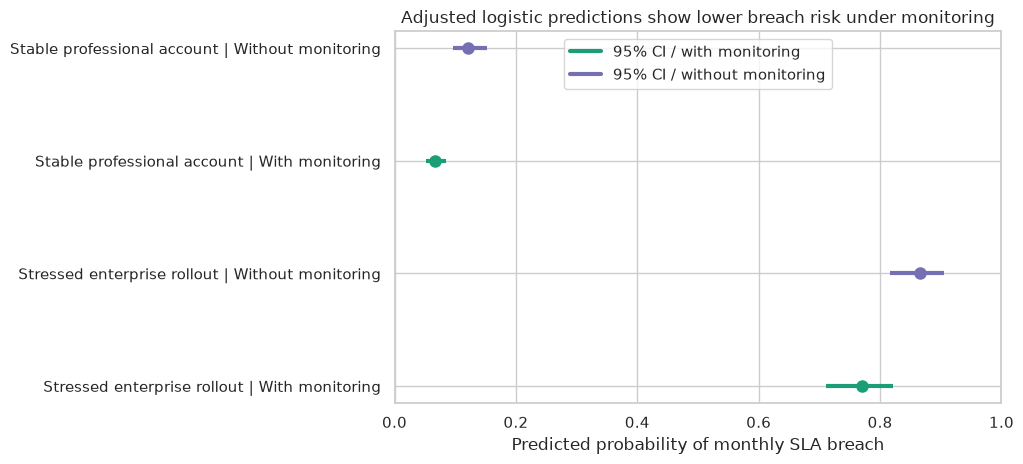

In [3]:
# Fit a logistic GLM for SLA breach risk and communicate effects through odds ratios and predicted probabilities.
logit_model = smf.glm(
    "sla_breach ~ priority_monitoring + C(plan_tier) + integration_count + np.log(usage_millions) + "
    "prior_incidents + ops_maturity + weekend_release + C(region)",
    data=df,
    family=sm.families.Binomial(),
).fit()

logit_terms = {
    "priority_monitoring": "Priority monitoring",
    "weekend_release": "Weekend release",
    "ops_maturity": "Ops maturity",
    "prior_incidents": "Prior incidents",
    "C(plan_tier)[T.Enterprise]": "Enterprise vs Standard",
}
logit_table = ratio_table(logit_model, logit_terms, "odds_ratio")
smart_display(logit_table)

scenario_base = pd.DataFrame(
    [
        {
            "scenario": "Stable professional account",
            "plan_tier": "Professional",
            "region": "North America",
            "integration_count": 4,
            "usage_millions": 3.2,
            "prior_incidents": 1,
            "ops_maturity": 0.8,
            "weekend_release": 0,
            "deploy_hours": 32.0,
        },
        {
            "scenario": "Stressed enterprise rollout",
            "plan_tier": "Enterprise",
            "region": "Latin America",
            "integration_count": 10,
            "usage_millions": 8.8,
            "prior_incidents": 4,
            "ops_maturity": -0.8,
            "weekend_release": 1,
            "deploy_hours": 88.0,
        },
    ]
)
scenario_base["plan_tier"] = pd.Categorical(scenario_base["plan_tier"], categories=PLAN_ORDER, ordered=True)
scenario_base["region"] = pd.Categorical(scenario_base["region"], categories=REGION_ORDER, ordered=True)

logit_scenarios = pd.concat(
    [
        scenario_base.assign(priority_monitoring=0),
        scenario_base.assign(priority_monitoring=1),
    ],
    ignore_index=True,
).sort_values(["scenario", "priority_monitoring"]).reset_index(drop=True)

logit_predictions = prediction_table_with_ci(logit_model, logit_scenarios, kind="probability")
logit_predictions["monitoring_label"] = np.where(
    logit_predictions["priority_monitoring"].eq(1),
    "With monitoring",
    "Without monitoring",
)
smart_display(logit_predictions)

fig, ax = plt.subplots(figsize=(10.4, 4.8))
plot_df = logit_predictions.copy()
plot_df["label"] = plot_df["scenario"] + " | " + plot_df["monitoring_label"]
y_positions = np.arange(len(plot_df))[::-1]
colors = np.where(plot_df["priority_monitoring"].eq(1), "#1b9e77", "#7570b3")

for y, (_, row), color in zip(y_positions, plot_df.iterrows(), colors):
    ax.hlines(y, row["mean_ci_lower"], row["mean_ci_upper"], color=color, linewidth=3)
    ax.plot(row["mean"], y, "o", color=color, markersize=8)

ax.set_yticks(y_positions)
ax.set_yticklabels(plot_df["label"])
ax.set_xlabel("Predicted probability of monthly SLA breach")
ax.set_title("Adjusted logistic predictions show lower breach risk under monitoring")
ax.set_xlim(0.0, 1.0)
ax.legend(
    handles=[
        plt.Line2D([0], [0], color="#1b9e77", linewidth=3, label="95% CI / with monitoring"),
        plt.Line2D([0], [0], color="#7570b3", linewidth=3, label="95% CI / without monitoring"),
    ],
    frameon=True,
    loc="upper center",
)

plt.tight_layout()
plt.show()


The raw summary suggested monitored accounts breached more often. The adjusted logistic model says the opposite. That is not a contradiction. It is the difference between an unadjusted descriptive comparison and a conditional risk comparison.

The odds ratio for `priority_monitoring` is well below 1, which means that after holding account complexity and operating context fixed, monitored accounts have lower breach odds. The scenario plot makes that concrete. Monitoring helps both profiles, but the absolute risk reduction is much larger for the stressed enterprise rollout, where baseline risk is already high.

This is a useful habit in applied work: for logistic regression, the model coefficient is not the best communication object for most stakeholders. The odds ratio is already better, and scenario-level predicted probabilities are usually better still.

## 4. Count Outcomes: Poisson Regression and Overdispersion

For the escalation outcome, the response is a nonnegative count. A standard Poisson GLM uses

$$
\log E[Y_i \mid X_i] = x_i^\top \beta.
$$

Exponentiating a coefficient gives an incidence-rate ratio: the multiplicative change in expected count associated with a one-unit predictor shift, holding the other variables fixed.

But count modeling comes with a practical warning. The Poisson model ties the conditional variance tightly to the conditional mean. In real operational data, escalation counts are often more variable than that. Tjur (1998) discusses this broader quasi-likelihood perspective, and Cameron and Trivedi (1990) developed regression-based tests for overdispersion in Poisson settings. Here we will use the Pearson dispersion diagnostic and compare classical and HC3 robust standard errors.


,term,label,estimate,std_error,ci_lower,ci_upper,incidence_rate_ratio,incidence_rate_ratio_ci_lower,incidence_rate_ratio_ci_upper
0,priority_monitoring,Priority monitoring,-0.197692,0.049880,-0.295455,-0.099930,0.820622,0.744193,0.904901
1,weekend_release,Weekend release,0.245235,0.038827,0.169136,0.321335,1.277922,1.184281,1.378967
2,ops_maturity,Ops maturity,-0.134261,0.017660,-0.168874,-0.099647,0.874362,0.844615,0.905157
3,prior_incidents,Prior incidents,0.118330,0.011476,0.095837,0.140823,1.125615,1.100580,1.151221
4,C(plan_tier)[T.Enterprise],Enterprise vs Standard,0.216119,0.066016,0.086730,0.345509,1.241250,1.090602,1.412709


,sample_mean_of_escalations,sample_variance_of_escalations,pearson_dispersion
0,3.933611,24.709401,3.407380


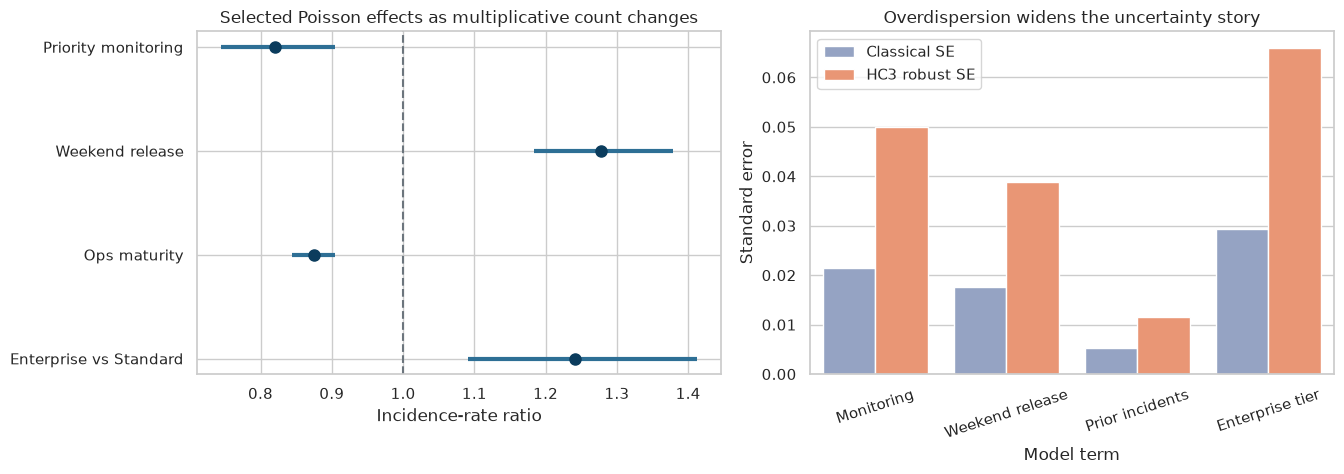

In [4]:
# Fit a Poisson count GLM and compare classical versus robust uncertainty under overdispersion.
poisson_model = smf.glm(
    "escalation_count ~ priority_monitoring + C(plan_tier) + integration_count + np.log(usage_millions) + "
    "prior_incidents + ops_maturity + weekend_release + C(region)",
    data=df,
    family=sm.families.Poisson(),
).fit()
poisson_robust = smf.glm(
    "escalation_count ~ priority_monitoring + C(plan_tier) + integration_count + np.log(usage_millions) + "
    "prior_incidents + ops_maturity + weekend_release + C(region)",
    data=df,
    family=sm.families.Poisson(),
).fit(cov_type="HC3")

poisson_terms = {
    "priority_monitoring": "Priority monitoring",
    "weekend_release": "Weekend release",
    "ops_maturity": "Ops maturity",
    "prior_incidents": "Prior incidents",
    "C(plan_tier)[T.Enterprise]": "Enterprise vs Standard",
}
poisson_table = ratio_table(poisson_robust, poisson_terms, "incidence_rate_ratio")
smart_display(poisson_table)

dispersion_table = pd.DataFrame(
    [
        {
            "sample_mean_of_escalations": df["escalation_count"].mean(),
            "sample_variance_of_escalations": df["escalation_count"].var(),
            "pearson_dispersion": ((poisson_model.resid_pearson ** 2).sum() / poisson_model.df_resid),
        }
    ]
)
smart_display(dispersion_table)

se_terms = ["priority_monitoring", "weekend_release", "prior_incidents", "C(plan_tier)[T.Enterprise]"]
term_labels = {
    "priority_monitoring": "Monitoring",
    "weekend_release": "Weekend release",
    "prior_incidents": "Prior incidents",
    "C(plan_tier)[T.Enterprise]": "Enterprise tier",
}
se_comparison = []
for term in se_terms:
    se_comparison.append(
        {
            "label": term_labels[term],
            "classical_se": poisson_model.bse[term],
            "hc3_se": poisson_robust.bse[term],
        }
    )
se_comparison = pd.DataFrame(se_comparison)

forest_df = poisson_table.loc[
    poisson_table["label"].isin(["Priority monitoring", "Weekend release", "Ops maturity", "Enterprise vs Standard"])
].copy()

fig, axes = plt.subplots(1, 2, figsize=(13.6, 4.9))

y_positions = np.arange(len(forest_df))[::-1]
for y, (_, row) in zip(y_positions, forest_df.iterrows()):
    axes[0].hlines(y, row["incidence_rate_ratio_ci_lower"], row["incidence_rate_ratio_ci_upper"], color="#2e6f95", linewidth=3)
    axes[0].plot(row["incidence_rate_ratio"], y, "o", color="#0b3c5d", markersize=8)

axes[0].axvline(1.0, color="#6c757d", linestyle="--", linewidth=1.5)
axes[0].set_yticks(y_positions)
axes[0].set_yticklabels(forest_df["label"])
axes[0].set_xlabel("Incidence-rate ratio")
axes[0].set_title("Selected Poisson effects as multiplicative count changes")

plot_se = se_comparison.melt(
    id_vars="label",
    value_vars=["classical_se", "hc3_se"],
    var_name="se_type",
    value_name="std_error",
)
plot_se["se_type"] = plot_se["se_type"].map({"classical_se": "Classical SE", "hc3_se": "HC3 robust SE"})

sns.barplot(
    data=plot_se,
    x="label",
    y="std_error",
    hue="se_type",
    palette=["#8da0cb", "#fc8d62"],
    ax=axes[1],
)
axes[1].set_title("Overdispersion widens the uncertainty story")
axes[1].set_xlabel("Model term")
axes[1].set_ylabel("Standard error")
axes[1].tick_params(axis="x", rotation=18)
axes[1].legend(title="", frameon=True)

plt.tight_layout()
plt.show()


The mean-variance comparison and the Pearson dispersion statistic both say the same thing: escalation counts are more variable than a simple equidispersion story would imply. That does **not** automatically make the Poisson mean model useless. It means we should be more careful about inference.

The substantive pattern is still informative. Priority monitoring has an incidence-rate ratio below 1, meaning it reduces expected escalation volume after adjustment. Weekend releases and prior incidents push counts upward, while better operational maturity pulls them down.

What changes under overdispersion is the uncertainty calculation. The HC3 robust standard errors are materially larger for several terms, especially the monitoring effect. That is a useful operational reminder: count-data models can look impressively precise until we acknowledge how noisy the process really is.

## 5. Rate Outcomes: Why Offsets Matter

A severe-incident count is rarely meaningful by itself when accounts differ substantially in exposure. A large enterprise with 80 deployment hours has more opportunities for incidents than a small account with 30 deployment hours, even if their underlying reliability rates are identical.

This is why rate models use an offset:

$$
\log E[Y_i \mid X_i, e_i] = \log e_i + x_i^\top \beta.
$$

Here $e_i$ is exposure. Moving $\log e_i$ to the left-hand side gives a model for the log incident rate. This lets the coefficients describe multiplicative rate changes with exposure handled explicitly.


,model,interpretation,estimate,effect_ratio,effect_ratio_ci_lower,effect_ratio_ci_upper
0,Poisson count model without offset,Multiplicative expected-count effect,-0.165248,0.847683,0.782536,0.918254
1,Poisson rate model with log-exposure offset,Incidence-rate ratio,-0.348500,0.705746,0.651312,0.764730


,scenario,monitoring_label,deploy_hours,mean,mean_ci_lower,mean_ci_upper,incidents_per_1000_deploy_hours,rate_ci_lower,rate_ci_upper
0,Stable professional account,Without monitoring,32.000000,0.386918,0.351247,0.426211,12.091188,10.976482,13.319098
1,Stable professional account,With monitoring,32.000000,0.273066,0.250658,0.297477,8.533310,7.833069,9.296149
2,Stressed enterprise rollout,Without monitoring,88.000000,5.564863,4.934953,6.275176,63.237078,56.079008,71.308822
3,Stressed enterprise rollout,With monitoring,88.000000,3.927381,3.594236,4.291404,44.629326,40.843596,48.765950


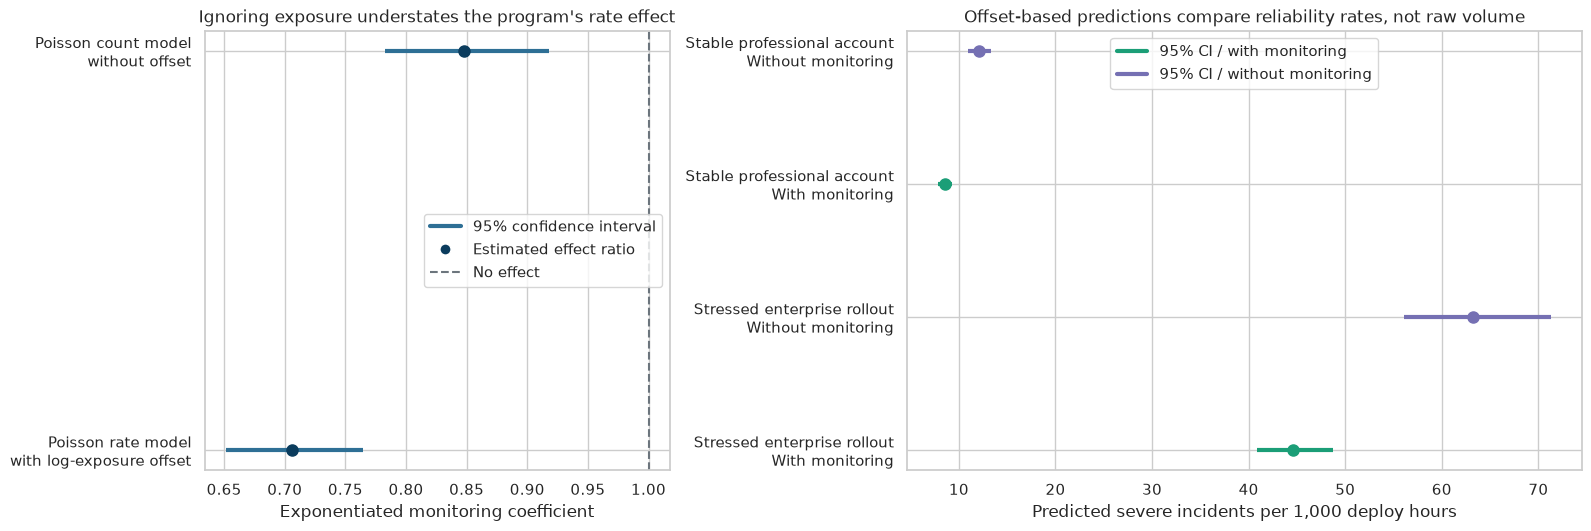

In [5]:
# Compare severe-incident count and rate models to show why exposure offsets change the estimand.
rate_model_no_offset = smf.glm(
    "sev1_count ~ priority_monitoring + C(plan_tier) + integration_count + prior_incidents + "
    "ops_maturity + weekend_release + C(region)",
    data=df,
    family=sm.families.Poisson(),
).fit()

rate_model_with_offset = smf.glm(
    "sev1_count ~ priority_monitoring + C(plan_tier) + integration_count + prior_incidents + "
    "ops_maturity + weekend_release + C(region)",
    data=df,
    family=sm.families.Poisson(),
    offset=np.log(df["deploy_hours"]),
).fit()

def effect_row(model, label, interpretation):
    """
    Extract the priority-monitoring effect from a severe-incident GLM.
    
    Parameters:
        model: Fitted Poisson GLM, either with or without the exposure offset.
        label: Human-readable model label used in the comparison table and plot.
        interpretation: Short text explaining whether the exponentiated coefficient is a count ratio or a rate ratio.
    
    Returns:
        A dictionary with the monitoring coefficient, exponentiated ratio, confidence limits, model label, and interpretation.
    
    Idea:
        Put the no-offset and offset models on a shared ratio scale so the role of exposure is visible.
    """
    lower, upper = model.conf_int().loc["priority_monitoring"]
    return {
        "model": label,
        "interpretation": interpretation,
        "estimate": model.params["priority_monitoring"],
        "effect_ratio": np.exp(model.params["priority_monitoring"]),
        "effect_ratio_ci_lower": np.exp(lower),
        "effect_ratio_ci_upper": np.exp(upper),
    }

offset_comparison = pd.DataFrame(
    [
        effect_row(
            rate_model_no_offset,
            "Poisson count model without offset",
            "Multiplicative expected-count effect",
        ),
        effect_row(
            rate_model_with_offset,
            "Poisson rate model with log-exposure offset",
            "Incidence-rate ratio",
        ),
    ]
)
smart_display(offset_comparison)

rate_scenarios = logit_scenarios.copy()
rate_predictions = rate_model_with_offset.get_prediction(
    rate_scenarios,
    offset=np.log(rate_scenarios["deploy_hours"]),
).summary_frame(alpha=0.05)
rate_summary = pd.concat([rate_scenarios.reset_index(drop=True), rate_predictions.reset_index(drop=True)], axis=1)
rate_summary["incidents_per_1000_deploy_hours"] = 1000 * rate_summary["mean"] / rate_summary["deploy_hours"]
rate_summary["rate_ci_lower"] = 1000 * rate_summary["mean_ci_lower"] / rate_summary["deploy_hours"]
rate_summary["rate_ci_upper"] = 1000 * rate_summary["mean_ci_upper"] / rate_summary["deploy_hours"]
rate_summary["monitoring_label"] = np.where(
    rate_summary["priority_monitoring"].eq(1),
    "With monitoring",
    "Without monitoring",
)
smart_display(
    rate_summary[
        [
            "scenario",
            "monitoring_label",
            "deploy_hours",
            "mean",
            "mean_ci_lower",
            "mean_ci_upper",
            "incidents_per_1000_deploy_hours",
            "rate_ci_lower",
            "rate_ci_upper",
        ]
    ]
)

fig, axes = plt.subplots(1, 2, figsize=(15.8, 5.2), gridspec_kw={"width_ratios": [1.0, 1.45]}, constrained_layout=True)

y_positions = np.arange(len(offset_comparison))[::-1]
for y, (_, row) in zip(y_positions, offset_comparison.iterrows()):
    axes[0].hlines(y, row["effect_ratio_ci_lower"], row["effect_ratio_ci_upper"], color="#2e6f95", linewidth=3)
    axes[0].plot(row["effect_ratio"], y, "o", color="#0b3c5d", markersize=8)

axes[0].axvline(1.0, color="#6c757d", linestyle="--", linewidth=1.5)
axes[0].set_yticks(y_positions)
axes[0].set_yticklabels(offset_comparison["model"].str.replace(" without ", "\nwithout ").str.replace(" with ", "\nwith "))
axes[0].set_xlabel("Exponentiated monitoring coefficient")
axes[0].set_title("Ignoring exposure understates the program's rate effect")
axes[0].legend(
    handles=[
        plt.Line2D([0], [0], color="#2e6f95", linewidth=3, label="95% confidence interval"),
        plt.Line2D([0], [0], marker="o", color="w", markerfacecolor="#0b3c5d", markersize=8, label="Estimated effect ratio"),
        plt.Line2D([0], [0], color="#6c757d", linestyle="--", linewidth=1.5, label="No effect"),
    ],
    frameon=True,
    loc="center right",
)

plot_rates = rate_summary.copy()
plot_rates["label"] = plot_rates["scenario"] + "\n" + plot_rates["monitoring_label"]
y2 = np.arange(len(plot_rates))[::-1]
colors = np.where(plot_rates["priority_monitoring"].eq(1), "#1b9e77", "#7570b3")

for y, (_, row), color in zip(y2, plot_rates.iterrows(), colors):
    axes[1].hlines(y, row["rate_ci_lower"], row["rate_ci_upper"], color=color, linewidth=3)
    axes[1].plot(row["incidents_per_1000_deploy_hours"], y, "o", color=color, markersize=8)

axes[1].set_yticks(y2)
axes[1].set_yticklabels(plot_rates["label"])
axes[1].set_xlabel("Predicted severe incidents per 1,000 deploy hours")
axes[1].set_title("Offset-based predictions compare reliability rates, not raw volume")
axes[1].legend(
    handles=[
        plt.Line2D([0], [0], color="#1b9e77", linewidth=3, label="95% CI / with monitoring"),
        plt.Line2D([0], [0], color="#7570b3", linewidth=3, label="95% CI / without monitoring"),
    ],
    frameon=True,
    loc="upper center",
)

plt.show()

The offset comparison is the cleanest lesson here. Without the exposure term, the model asks whether monitored accounts have fewer severe incidents in absolute count. With the offset, the model asks whether they have fewer severe incidents **per unit of deployment exposure**.

That distinction matters for interpretation. In the left panel, the no-offset model's exponentiated coefficient is a multiplicative **count** effect, whereas the offset model's exponentiated coefficient is a true **rate** effect. Because monitored accounts are systematically larger, the no-offset model understates the benefit of the program. Once exposure is acknowledged, the estimated rate reduction becomes stronger.

The scenario panel makes that visible in operational units: incidents per 1,000 deploy hours. This is one of the most common modeling mistakes in practice. Analysts notice that larger customers have more incidents and then interpret raw count differences as quality differences, when much of the story is simply exposure.

## 6. One Decision Dashboard Across Outcome Types

A real stakeholder usually does not care that one result came from a logistic model and another came from a Poisson model. They want one integrated answer:

- does the program reduce the chance of breach,
- does it reduce the expected workload from escalations, and
- does it improve severe-incident rates after exposure is accounted for?

We can answer all three with one scenario dashboard.


In [6]:
# Combine binary, count, and rate scenario predictions into one decision dashboard.
count_predictions = prediction_table_with_ci(poisson_model, logit_scenarios)
count_predictions["monitoring_label"] = np.where(
    count_predictions["priority_monitoring"].eq(1),
    "With monitoring",
    "Without monitoring",
)

dashboard = logit_predictions[
    ["scenario", "monitoring_label", "mean", "mean_ci_lower", "mean_ci_upper"]
].rename(
    columns={
        "mean": "predicted_breach_probability",
        "mean_ci_lower": "breach_ci_lower",
        "mean_ci_upper": "breach_ci_upper",
    }
).merge(
    count_predictions[
        ["scenario", "monitoring_label", "mean", "mean_ci_lower", "mean_ci_upper"]
    ].rename(
        columns={
            "mean": "predicted_escalation_count",
            "mean_ci_lower": "escalation_ci_lower",
            "mean_ci_upper": "escalation_ci_upper",
        }
    ),
    on=["scenario", "monitoring_label"],
).merge(
    rate_summary[
        ["scenario", "monitoring_label", "incidents_per_1000_deploy_hours", "rate_ci_lower", "rate_ci_upper"]
    ],
    on=["scenario", "monitoring_label"],
)

smart_display(dashboard)


,scenario,monitoring_label,predicted_breach_probability,breach_ci_lower,breach_ci_upper,predicted_escalation_count,escalation_ci_lower,escalation_ci_upper,incidents_per_1000_deploy_hours,rate_ci_lower,rate_ci_upper
0,Stable professional account,Without monitoring,0.121320,0.096159,0.151958,2.342803,2.221695,2.470512,12.091188,10.976482,13.319098
1,Stable professional account,With monitoring,0.066855,0.052568,0.084678,1.922556,1.830604,2.019127,8.533310,7.833069,9.296149
2,Stressed enterprise rollout,Without monitoring,0.866243,0.815540,0.904638,14.266626,13.316360,15.284704,63.237078,56.079008,71.308822
3,Stressed enterprise rollout,With monitoring,0.770669,0.711508,0.820754,11.707512,11.094255,12.354668,44.629326,40.843596,48.765950


The dashboard is useful because it puts different outcome scales into one decision frame. The breach probability answers a binary reliability question, the escalation count answers a workload question, and the severe-incident rate answers an exposure-adjusted safety question. Agreement across all three outcomes is stronger evidence than a single favorable coefficient.

In [7]:
# Translate the GLM dashboard into a written for stakeholders monitoring recommendation.
stressed_without = dashboard.loc[
    (dashboard["scenario"].eq("Stressed enterprise rollout"))
    & (dashboard["monitoring_label"].eq("Without monitoring"))
].iloc[0]
stressed_with = dashboard.loc[
    (dashboard["scenario"].eq("Stressed enterprise rollout"))
    & (dashboard["monitoring_label"].eq("With monitoring"))
].iloc[0]

stable_without = dashboard.loc[
    (dashboard["scenario"].eq("Stable professional account"))
    & (dashboard["monitoring_label"].eq("Without monitoring"))
].iloc[0]
stable_with = dashboard.loc[
    (dashboard["scenario"].eq("Stable professional account"))
    & (dashboard["monitoring_label"].eq("With monitoring"))
].iloc[0]

memo = f"""
## 7. Decision Memo

**Question.** Should the company continue funding priority monitoring, and which accounts should receive it first?

**Binary risk answer.** In the stressed enterprise scenario, monitoring lowers the predicted monthly SLA-breach probability from **{stressed_without['predicted_breach_probability']:.3f}** to **{stressed_with['predicted_breach_probability']:.3f}**. The same direction holds for the stable professional account, but the absolute risk reduction is smaller.

**Workload answer.** Monitoring also lowers the expected monthly escalation count. For the stressed enterprise rollout, the expected count falls from **{stressed_without['predicted_escalation_count']:.2f}** to **{stressed_with['predicted_escalation_count']:.2f}**. That means the program is reducing both binary failure risk and expected operational load.

**Rate answer.** After exposure adjustment, the severe-incident rate for the stressed enterprise scenario falls from **{stressed_without['incidents_per_1000_deploy_hours']:.2f}** to **{stressed_with['incidents_per_1000_deploy_hours']:.2f}** incidents per 1,000 deploy hours. This is the most decision-relevant reliability comparison because it accounts for account size.

**Recommendation.** Keep the priority-monitoring program and allocate it first to large, high-stress enterprise rollouts. The adjusted GLMs show consistent improvement across breach risk, escalation volume, and severe-incident rate, even though the raw descriptive comparisons initially made monitored accounts look worse.
"""

display(Markdown(memo))



## 7. Decision Memo

**Question.** Should the company continue funding priority monitoring, and which accounts should receive it first?

**Binary risk answer.** In the stressed enterprise scenario, monitoring lowers the predicted monthly SLA-breach probability from **0.866** to **0.771**. The same direction holds for the stable professional account, but the absolute risk reduction is smaller.

**Workload answer.** Monitoring also lowers the expected monthly escalation count. For the stressed enterprise rollout, the expected count falls from **14.27** to **11.71**. That means the program is reducing both binary failure risk and expected operational load.

**Rate answer.** After exposure adjustment, the severe-incident rate for the stressed enterprise scenario falls from **63.24** to **44.63** incidents per 1,000 deploy hours. This is the most decision-relevant reliability comparison because it accounts for account size.

**Recommendation.** Keep the priority-monitoring program and allocate it first to large, high-stress enterprise rollouts. The adjusted GLMs show consistent improvement across breach risk, escalation volume, and severe-incident rate, even though the raw descriptive comparisons initially made monitored accounts look worse.


The memo is model-based evidence, not proof that monitoring caused every improvement. The value of the GLM workflow is that it makes the outcome scale, adjustment set, exposure normalization, and decision threshold explicit enough for a stakeholder to audit.

<!-- real-data-companion-course01 -->
## Real-Data Companion: Grouped-Binomial GLM with STAR98

The STAR98 dataset records grouped education outcomes for California counties. The response is not a single continuous measurement. It is a pair of counts: students above and below the national median on a standardized test. That makes STAR98 a clean real-data companion for grouped-binomial generalized linear models.

The unit is a county-level aggregate, and each row has a known number of tested students. The model therefore needs to respect both the number of successes and the number of trials. Treating the outcome as an ordinary continuous percentage would discard information about denominator size and uncertainty.

The companion fits a grouped-binomial GLM to connect outcome scale with model family. The goal is not to build a definitive education accountability model. The goal is to show that binary, count, and rate data require likelihoods that match how the data were measured.

For clarity, the unit is a county-level aggregate. The outcome is grouped test performance, represented as successes and failures out of a known number of students. The experiment fits a grouped-binomial GLM so the likelihood matches the denominator structure.

Data source: [STAR98 data in statsmodels](https://www.statsmodels.org/stable/datasets/generated/star98.html).

,term,Coef.,Std.Err.,P>|z|
0,const,0.685,0.067,0.000
1,LOWINC,-0.016,0.000,0.000
2,PERASIAN,0.014,0.001,0.000
3,PERBLACK,-0.018,0.001,0.000
4,PERHISP,-0.012,0.000,0.000
5,PTRATIO,-0.005,0.003,0.079
6,PCTAF,0.009,0.000,0.000


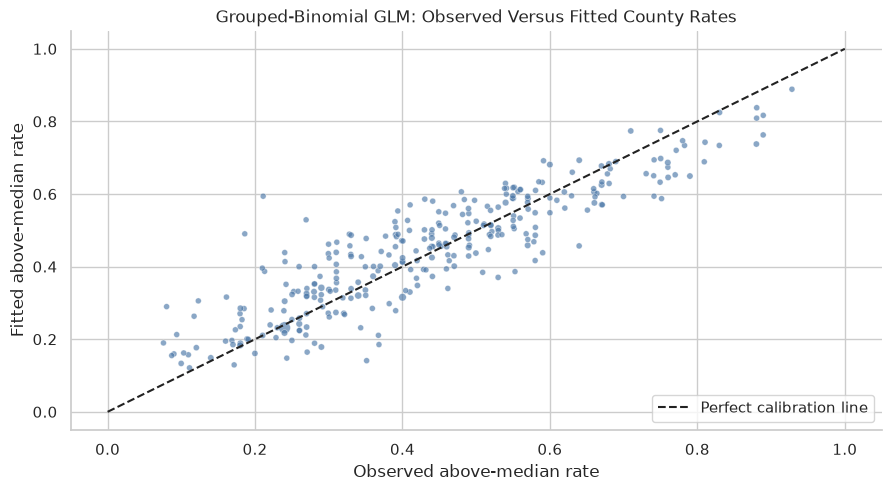

In [8]:
# real-data-companion-course01
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.api as sm


def _find_project_root(start=Path.cwd()):
    """
    Locate the portfolio root so shared notebook helpers import reliably.
    
    Parameters:
        start: Starting path for the upward project-root search.
    
    Returns:
        A `Path` pointing to the nearest portfolio root that contains `notebooks/_shared`; if no such parent is found, the original starting path is returned.
    """

    for candidate in [start, *start.parents]:
        if (candidate / "notebooks" / "_shared").exists():
            return candidate
    return start


PROJECT_ROOT = _find_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from notebooks._shared.display import smart_display
from notebooks._shared.real_data import load_statsmodels_star98, optional_data_note

RUN_REAL_DATA_COMPANION = True

if RUN_REAL_DATA_COMPANION:
    star = load_statsmodels_star98().copy()
    star["tested"] = star["NABOVE"] + star["NBELOW"]
    star["above_rate"] = star["NABOVE"] / star["tested"]

    y = star[["NABOVE", "NBELOW"]]
    X = sm.add_constant(star[["LOWINC", "PERASIAN", "PERBLACK", "PERHISP", "PTRATIO", "PCTAF"]])
    grouped_logit = sm.GLM(y, X, family=sm.families.Binomial()).fit()

    coef_table = grouped_logit.summary2().tables[1].reset_index().rename(columns={"index": "term"})
    smart_display(coef_table[["term", "Coef.", "Std.Err.", "P>|z|"]].round(4))

    star["predicted_rate"] = grouped_logit.predict(X)
    fig, ax = plt.subplots(figsize=(8.8, 4.8), constrained_layout=True)
    sns.scatterplot(data=star, x="above_rate", y="predicted_rate", size="tested", alpha=0.65, color="#4C78A8", ax=ax, legend=False)
    ax.plot([0, 1], [0, 1], color="#222222", linestyle="--", linewidth=1.5, label="Perfect calibration line")
    ax.set_title("Grouped-Binomial GLM: Observed Versus Fitted County Rates")
    ax.set_xlabel("Observed above-median rate")
    ax.set_ylabel("Fitted above-median rate")
    ax.legend(frameon=True, loc="lower right")
    sns.despine(fig=fig)
    plt.show()
else:
    optional_data_note(
        "STAR98 California Education Data",
        "https://www.statsmodels.org/stable/datasets/generated/star98.html",
        "RUN_REAL_DATA_COMPANION",
    )

<!-- real-data-companion-course01 -->
The real-data GLM illustrates why outcome type matters. Treating the county rate as an ordinary continuous outcome would discard the tested-student denominator. The grouped-binomial model keeps the successes and failures together, so larger counties carry more information than smaller counties with the same observed rate.

The scatterplot is a calibration check, not a claim that the model is perfect. Points near the diagonal have fitted rates close to observed rates, while deviations from the line indicate counties where the covariates do not fully explain the achievement rate. That is the right GLM habit: match the outcome structure first, then check how well the fitted mean describes the observed pattern.

## What to Remember

1. GLMs extend regression by matching the outcome scale to the model scale.
2. Logistic regression is for probabilities, Poisson regression is for counts, and offsets are what turn counts into rates.
3. Exponentiated coefficients should be interpreted as odds ratios or incidence-rate ratios, not as additive changes.
4. Raw treated-versus-untreated comparisons can be misleading when harder units are more likely to receive an intervention.
5. Overdispersion can preserve the Poisson mean model while making naive uncertainty statements too optimistic.
6. Offsets are not a cosmetic adjustment. They change the question from “how many events?” to “how many events per unit exposure?”
7. Scenario predictions are often the best bridge from GLM output to stakeholder decisions.


## References

- Cameron, A. C., & Trivedi, P. K. (1990). *Regression-based tests for overdispersion in the Poisson model.* *Journal of Econometrics, 46*(3), 347-364. [https://doi.org/10.1016/0304-4076(90)90014-K](https://doi.org/10.1016/0304-4076%2890%2990014-K)
- Nelder, J. A., & Wedderburn, R. W. M. (1972). *Generalized linear models.* *Journal of the Royal Statistical Society: Series A (General), 135*(3), 370-384. [https://doi.org/10.2307/2344614](https://doi.org/10.2307/2344614)
- Tjur, T. (1998). *Nonlinear regression, quasi likelihood, and overdispersion in generalized linear models.* *The American Statistician, 52*(3), 222-227. [https://doi.org/10.2307/2685928](https://doi.org/10.2307/2685928)
